# Control supervisado de separabilidad

Este diagnóstico pregunta si la reconstrucción del dataset y el mismo encoder convolucional contienen suficiente información para distinguir los 18 regímenes cuando se entregan labels. Usa exactamente train/validation de escala media y no construye test.

Se reemplaza el objetivo JEPA por una cabeza lineal de 18 clases con cross-entropy. Antes de ejecutar se exige al menos `85%` de accuracy ordinaria y `90%` al considerar `sine_med_freq` y `sine_low_amp` como una clase observable equivalente. Un PASS localiza el cuello en el objetivo/receta autosupervisada; un FAIL obliga a volver al generador o al encoder.

In [1]:
# ruff: noqa: E402, E501
import copy
import json
import math
import random
import sys
import time
from dataclasses import asdict
from pathlib import Path

ROOT = Path.cwd()
if not (ROOT / "pyproject.toml").exists():
    ROOT = ROOT.parent
assert (ROOT / "pyproject.toml").exists()
sys.path.insert(0, str(ROOT / "src"))

import matplotlib.pyplot as plt
import numpy as np
import torch
from IPython.display import Markdown, display
from sklearn.metrics import confusion_matrix
from torch import nn

from koopman_jepa.paper_config import load_paper_mlp_one_hidden_development_config
from koopman_jepa.paper_data import PAPER_REGIME_NAMES, PaperRegimeDataset, generate_paper_master
from koopman_jepa.paper_evaluation import evaluate_paper_mlp_seed_clustering
from koopman_jepa.paper_model import PaperTemporalEncoder
from koopman_jepa.paper_training import make_paper_loader

plt.style.use("seaborn-v0_8-whitegrid")
torch.use_deterministic_algorithms(True)

In [2]:
config = load_paper_mlp_one_hidden_development_config(
    ROOT / "configs" / "paper_mlp_medium_scale_development.yaml"
)
train_dataset = PaperRegimeDataset(config.data, "train", generate_paper_master)
validation_dataset = PaperRegimeDataset(config.data, "val", generate_paper_master)
train_keys = {train_dataset.sample_key(i) for i in range(len(train_dataset))}
validation_keys = {validation_dataset.sample_key(i) for i in range(len(validation_dataset))}
assert config.data.train_per_regime == 256
assert config.data.val_per_regime == 64
assert len(train_dataset) == 4608
assert len(validation_dataset) == 1152
assert train_keys.isdisjoint(validation_keys)
assert config.model.encoder_projection == "direct"
assert config.model.latent_dim == 32
assert config.train.learning_rate == 3e-4
assert config.train.epochs == 20
print(json.dumps({"data": asdict(config.data), "model": asdict(config.model), "train": asdict(config.train)}, indent=2))
print(f"Train/validation: {len(train_dataset)}/{len(validation_dataset)}. Test no fue instanciado.")

{
  "data": {
    "master_length": 1024,
    "context_length": 768,
    "shift": 256,
    "train_per_regime": 256,
    "val_per_regime": 64,
    "test_per_regime": 64,
    "base_seed": 1,
    "normalization": "per_sequence"
  },
  "model": {
    "latent_dim": 32,
    "input_length": 768,
    "encoder_projection": "direct",
    "predictor_kind": "mlp",
    "linear_initialization": "identity",
    "mlp_depth": "one_hidden",
    "ema_decay": 0.996
  },
  "train": {
    "optimizer": "adamw",
    "learning_rate": 0.0003,
    "weight_decay": 0.0,
    "batch_size": 64,
    "epochs": 20,
    "seed": 10,
    "device": "cpu",
    "num_workers": 0,
    "max_gradient_norm": null,
    "learning_rate_schedule": "constant",
    "learning_rate_decay_epoch": null,
    "learning_rate_decay_factor": 0.1
  }
}
Train/validation: 4608/1152. Test no fue instanciado.


In [3]:
class SupervisedEncoderClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = PaperTemporalEncoder(
            latent_dim=config.model.latent_dim,
            projection=config.model.encoder_projection,
            input_length=config.model.input_length,
        )
        self.classifier = nn.Linear(config.model.latent_dim, len(PAPER_REGIME_NAMES))

    def forward(self, inputs):
        embeddings = self.encoder(inputs)
        return embeddings, self.classifier(embeddings)

@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()
    total_loss, total_correct, count = 0.0, 0, 0
    all_embeddings, all_labels, all_predictions = [], [], []
    for context, _, labels in loader:
        context, labels = context.to(device), labels.to(device)
        embeddings, logits = model(context)
        loss = nn.functional.cross_entropy(logits, labels)
        predictions = logits.argmax(dim=1)
        batch_size = labels.shape[0]
        total_loss += float(loss) * batch_size
        total_correct += int((predictions == labels).sum())
        count += batch_size
        all_embeddings.append(embeddings.cpu().numpy())
        all_labels.append(labels.cpu().numpy())
        all_predictions.append(predictions.cpu().numpy())
    return {
        "loss": total_loss / count,
        "accuracy": total_correct / count,
        "embeddings": np.concatenate(all_embeddings),
        "labels": np.concatenate(all_labels),
        "predictions": np.concatenate(all_predictions),
    }

In [4]:
seed = 10
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
device = torch.device(config.train.device)
model = SupervisedEncoderClassifier().to(device)
optimizer = torch.optim.AdamW(
    model.parameters(), lr=config.train.learning_rate, weight_decay=config.train.weight_decay
)
train_loader = make_paper_loader(train_dataset, config.train, shuffle=True)
validation_loader = make_paper_loader(validation_dataset, config.train, shuffle=False)
history, best_state, best_epoch, best_accuracy = [], None, 0, -math.inf
started = time.perf_counter()

for epoch in range(1, config.train.epochs + 1):
    model.train()
    train_loss_total, train_correct, train_count = 0.0, 0, 0
    for context, _, labels in train_loader:
        context, labels = context.to(device), labels.to(device)
        optimizer.zero_grad(set_to_none=True)
        _, logits = model(context)
        loss = nn.functional.cross_entropy(logits, labels)
        loss.backward()
        optimizer.step()
        batch_size = labels.shape[0]
        train_loss_total += float(loss.detach()) * batch_size
        train_correct += int((logits.argmax(dim=1) == labels).sum())
        train_count += batch_size
    validation = evaluate(model, validation_loader, device)
    row = {
        "epoch": epoch,
        "train_loss": train_loss_total / train_count,
        "train_accuracy": train_correct / train_count,
        "validation_loss": validation["loss"],
        "validation_accuracy": validation["accuracy"],
    }
    history.append(row)
    if row["validation_accuracy"] > best_accuracy:
        best_accuracy = row["validation_accuracy"]
        best_epoch = epoch
        best_state = copy.deepcopy(model.state_dict())
    print(f"epoch={epoch:02d} train_acc={row['train_accuracy']:.2%} val_acc={row['validation_accuracy']:.2%} val_loss={row['validation_loss']:.4f}")

assert best_state is not None
model.load_state_dict(best_state)
validation = evaluate(model, validation_loader, device)
elapsed = time.perf_counter() - started
assert validation["accuracy"] == best_accuracy
print(f"Best epoch={best_epoch}; validation accuracy={best_accuracy:.2%}; time={elapsed:.1f}s")

epoch=01 train_acc=31.97% val_acc=53.12% val_loss=1.4925


epoch=02 train_acc=61.41% val_acc=66.06% val_loss=0.9089


epoch=03 train_acc=73.76% val_acc=79.86% val_loss=0.6007


epoch=04 train_acc=83.09% val_acc=82.29% val_loss=0.4633


epoch=05 train_acc=86.85% val_acc=86.72% val_loss=0.4094


...

epoch=17 train_acc=91.99% val_acc=89.50% val_loss=0.2276


epoch=18 train_acc=91.78% val_acc=91.49% val_loss=0.1999


epoch=19 train_acc=92.04% val_acc=90.80% val_loss=0.2043


epoch=20 train_acc=92.12% val_acc=89.67% val_loss=0.2141


Best epoch=18; validation accuracy=91.49%; time=57.6s


In [5]:
MIN_VALIDATION_ACCURACY = 0.85
MIN_PAIR_AWARE_ACCURACY = 0.90
med_id = PAPER_REGIME_NAMES.index("sine_med_freq")
low_amp_id = PAPER_REGIME_NAMES.index("sine_low_amp")
pair_labels = validation["labels"].copy()
pair_predictions = validation["predictions"].copy()
pair_labels[pair_labels == low_amp_id] = med_id
pair_predictions[pair_predictions == low_amp_id] = med_id
pair_aware_accuracy = float(np.mean(pair_labels == pair_predictions))
matrix = confusion_matrix(
    validation["labels"], validation["predictions"], labels=np.arange(len(PAPER_REGIME_NAMES)), normalize="true"
)
macro_recall = float(np.diag(matrix).mean())
clustering = evaluate_paper_mlp_seed_clustering(
    validation["embeddings"], validation["labels"], seed, config.clustering
)
probe_passed = bool(
    validation["accuracy"] >= MIN_VALIDATION_ACCURACY
    and pair_aware_accuracy >= MIN_PAIR_AWARE_ACCURACY
)
print(json.dumps({"best_epoch": best_epoch, "validation_accuracy": validation["accuracy"], "pair_aware_accuracy": pair_aware_accuracy, "macro_recall": macro_recall, "embedding_kmeans": asdict(clustering), "passed": probe_passed}, indent=2))

{
  "best_epoch": 18,
  "validation_accuracy": 0.9149305555555556,
  "pair_aware_accuracy": 0.9644097222222222,
  "macro_recall": 0.9149305555555556,
  "embedding_kmeans": {
    "seed": 10,
    "mean_purity": 0.8805121527777777,
    "purity_std": 0.004307821354416438,
    "minimum_purity": 0.8715277777777778,
    "maximum_purity": 0.8836805555555556,
    "mean_matched_accuracy": 0.8564670138888889,
    "purities": [
      0.8828125,
      0.8715277777777778,
      0.8715277777777778,
      0.8836805555555556,
      0.8819444444444444,
      0.8828125,
      0.8828125,
      0.8819444444444444,
      0.8828125,
      0.8828125,
      0.8828125,
      0.8723958333333334,
      0.8828125,
      0.8836805555555556,
      0.8828125,
      0.8819444444444444,
      0.8828125,
      0.8819444444444444,
      0.8723958333333334,
      0.8819444444444444
    ],
    "matched_accuracies": [
      0.8585069444444444,
      0.8463541666666666,
      0.8454861111111112,
      0.859375,
      0.86024

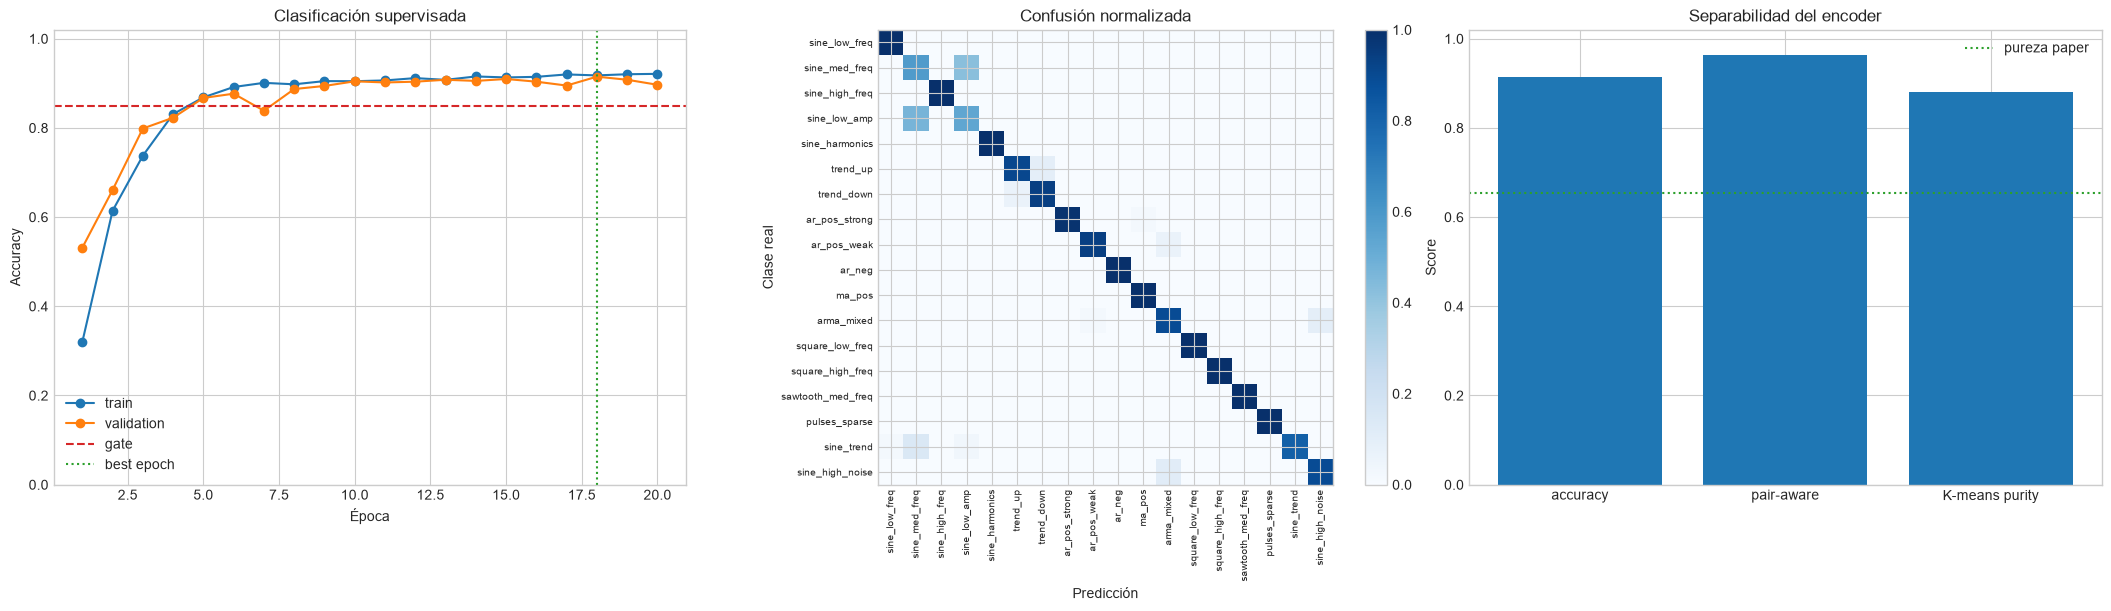

## Análisis del resultado

- Resultado del control: **PASS**.
- Mejor época: **18**.
- Accuracy ordinaria: **91.49%**; macro-recall: **91.49%**.
- Accuracy tratando el par de senos indistinguible como equivalente: **96.44%**.
- Pureza K-means de los embeddings supervisados: **88.05% ± 0.43%**.

Un PASS demuestra capacidad de datos+encoder bajo supervisión, no reproduce el paper ni valida JEPA. Un FAIL devuelve la investigación al generador o a la arquitectura. Test no fue construido ni consultado.


In [6]:
epochs = np.array([row["epoch"] for row in history])
train_accuracy = np.array([row["train_accuracy"] for row in history])
validation_accuracy = np.array([row["validation_accuracy"] for row in history])
fig, axes = plt.subplots(1, 3, figsize=(21, 6), constrained_layout=True)
axes[0].plot(epochs, train_accuracy, marker="o", label="train")
axes[0].plot(epochs, validation_accuracy, marker="o", label="validation")
axes[0].axhline(MIN_VALIDATION_ACCURACY, color="tab:red", linestyle="--", label="gate")
axes[0].axvline(best_epoch, color="tab:green", linestyle=":", label="best epoch")
axes[0].set(title="Clasificación supervisada", xlabel="Época", ylabel="Accuracy", ylim=(0, 1.02))
axes[0].legend()
image = axes[1].imshow(matrix, vmin=0, vmax=1, cmap="Blues")
axes[1].set(title="Confusión normalizada", xlabel="Predicción", ylabel="Clase real")
axes[1].set_xticks(np.arange(len(PAPER_REGIME_NAMES)), PAPER_REGIME_NAMES, rotation=90, fontsize=7)
axes[1].set_yticks(np.arange(len(PAPER_REGIME_NAMES)), PAPER_REGIME_NAMES, fontsize=7)
fig.colorbar(image, ax=axes[1], fraction=0.046)
axes[2].bar(["accuracy", "pair-aware", "K-means purity"], [validation["accuracy"], pair_aware_accuracy, clustering.mean_purity])
axes[2].axhline(0.6548, color="tab:green", linestyle=":", label="pureza paper")
axes[2].set(title="Separabilidad del encoder", ylabel="Score", ylim=(0, 1.02))
axes[2].legend()
plt.show()

display(Markdown(f"""## Análisis del resultado

- Resultado del control: **{'PASS' if probe_passed else 'FAIL'}**.
- Mejor época: **{best_epoch}**.
- Accuracy ordinaria: **{validation['accuracy']:.2%}**; macro-recall: **{macro_recall:.2%}**.
- Accuracy tratando el par de senos indistinguible como equivalente: **{pair_aware_accuracy:.2%}**.
- Pureza K-means de los embeddings supervisados: **{clustering.mean_purity:.2%} ± {clustering.purity_std:.2%}**.

Un PASS demuestra capacidad de datos+encoder bajo supervisión, no reproduce el paper ni valida JEPA. Un FAIL devuelve la investigación al generador o a la arquitectura. Test no fue construido ni consultado.
"""))